# 07 — CIFAR-100: 100-Class Image Classification

CIFAR-100 is 60,000 color images (32×32 pixels) across **100 classes** — everything from airplanes and dogs to mushrooms and clocks. Unlike CIFAR-10 (10 broad categories), CIFAR-100 has fine-grained classes.

**Why CIFAR-100 is a real deep learning challenge:**
- **100 classes** — the model must learn to distinguish far more categories than MNIST (10) or CIFAR-10 (10)
- **32×32 color images** — low resolution makes fine-grained discrimination hard
- **Only 500 images per class** — the model needs to generalize from limited examples
- **No pre-trained ResNet** — you build and train the CNN from scratch

Your goal: build a CNN that achieves **>65% test accuracy** (beating random chance of 1% by a huge margin, and matching where simple CNNs plateau on this dataset).

In [28]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path

from sklearn.metrics import confusion_matrix
import seaborn as sns

# Device detection — works on Windows (CUDA), Mac (MPS/CPU), and Linux (CUDA/CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Set random seeds for reproducibility (works across all platforms)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Random seed set to {SEED}')

Using device: mps
Random seed set to 42


## Step 1: Load the Data with Augmentation

CIFAR-100 is built into torchvision — it downloads automatically on first run (~160MB).

**Data augmentation** is critical for CIFAR-100 because there are only 500 images per class. Without augmentation, the model will memorize rather than generalize.

We apply different transforms to training vs. test data:
- **Training**: random horizontal flips, random shifts, and color jitter — these create "new" training examples from existing ones
- **Test**: only resize and normalize — we want consistent evaluation

This is the same idea behind augmentations you'd use on any real-world image dataset.

In [29]:
data_dir = Path.home() / "LocalAI" / "data"

# CIFAR-100 mean and std (pre-computed over the whole dataset)
CIFAR_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR_STD  = (0.2675, 0.2565, 0.2761)

# Training: heavy augmentation + normalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Test: just resize + normalize (no randomness)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_dataset = datasets.CIFAR100(
    root=data_dir / "cifar100", train=True,  download=True, transform=train_transform
)
test_dataset = datasets.CIFAR100(
    root=data_dir / "cifar100", train=False, download=True, transform=test_transform
)

# num_workers=0 is safest for cross-platform (Windows/Mac/Linux all work fine)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

print(f"Data directory: {data_dir}")
print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Image shape:      {train_dataset[0][0].shape}")  # [C, H, W]

# Show the class names (first 20)
print(f"\nClass labels (first 20 of 100):")
for i, name in enumerate(train_dataset.classes[:20]):
    print(f"  {i:3d}: {name}")

Data directory: /Users/zlee/LocalAI/data
Training samples: 50000
Test samples:     10000
Number of classes: 100
Image shape:      torch.Size([3, 32, 32])

Class labels (first 20 of 100):
    0: apple
    1: aquarium_fish
    2: baby
    3: bear
    4: beaver
    5: bed
    6: bee
    7: beetle
    8: bicycle
    9: bottle
   10: bowl
   11: boy
   12: bridge
   13: bus
   14: butterfly
   15: camel
   16: can
   17: castle
   18: caterpillar
   19: cattle


## Step 2: Visualize Some Samples

Always look at your data first. With 100 classes, it's especially important to see what kinds of images the model needs to distinguish.

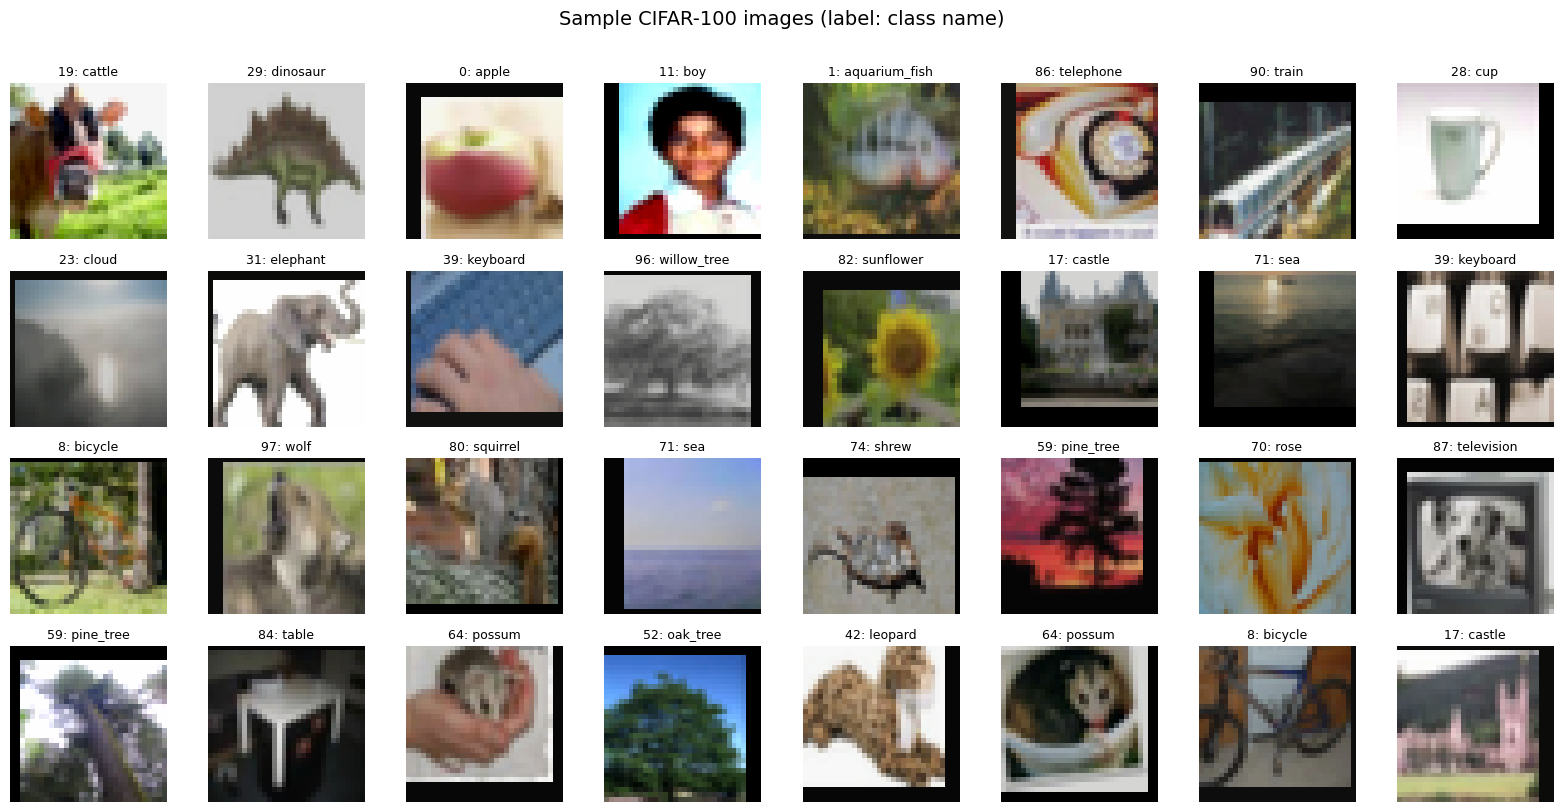

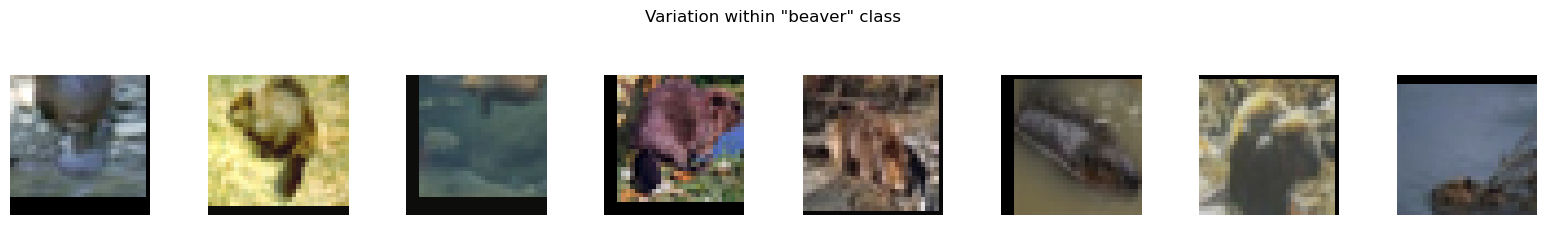

In [30]:
# CIFAR-100 class names
classes = train_dataset.classes

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    img = image.numpy().transpose(1, 2, 0)
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(f'{label}: {classes[label]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Sample CIFAR-100 images (label: class name)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# Show samples from a single class to see intra-class variation
class_idx = 4
class_name = classes[class_idx]
class_samples = [train_dataset[i] for i in range(len(train_dataset)) if train_dataset[i][1] == class_idx][:8]

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, (img, _) in zip(axes, class_samples):
    img_display = img.numpy().transpose(1, 2, 0)
    img_display = img_display * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.axis('off')
plt.suptitle(f'Variation within "{class_name}" class', y=1.1, fontsize=12)
plt.tight_layout()
plt.show()

## Step 3: Build a Deeper CNN

A 2-layer CNN (like the one in MNIST) won't cut it for CIFAR-100. With 100 classes and only 32×32 pixels, the model needs:

1. **More convolutional layers** — to extract increasingly abstract features
2. **More filters per layer** — to capture diverse patterns across 100 classes
3. **Batch normalization** — stabilizes training for deeper networks (standardizes layer outputs)
4. **Dropout** — prevents overfitting (more important when each class has only 500 examples)
5. **Wider fully-connected layers** — 100 classes need more capacity at the end

The architecture below follows the "VGG-style" pattern: stack of 3×3 conv layers with increasing filter counts (64 → 128 → 256 → 512), each followed by batch norm + ReLU + max pooling.

**New building blocks in this notebook:**
- `nn.BatchNorm2d()` — normalizes activations across each batch, allows higher learning rates and reduces overfitting
- Deeper stacking of conv layers (4 conv blocks instead of 2)

In [31]:
class Cifar100CNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        # Feature extractor: 5 convolutional blocks
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4: 4x4 -> 2x2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 5: 2x2 -> 1x1 (extra depth)
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Classifier: 2 fully-connected layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = Cifar100CNN().to(device)
print(model)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Cifar100CNN(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128,

## Step 4: Save a Model Checkpoint

Now that the model is built, let's set up checkpointing so you can save your trained weights later.

This defines two helper functions:
- `save_checkpoint()` — saves the model after training
- `load_checkpoint()` — loads a previously saved checkpoint (useful if you restart the notebook and want to skip re-training)

In [32]:
# --- Checkpoint Setup ---
checkpoint_dir = Path.home() / "LocalAI" / "models" / "cifar100"
checkpoint_dir.mkdir(parents=True, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, loss, accuracy, filename=None):
    """Save model checkpoint with full training state."""
    if filename is None:
        filename = f"cifar100_epoch_{epoch+1:02d}_{accuracy:.2%}.pt"
    checkpoint_path = checkpoint_dir / filename

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'loss': loss,
        'accuracy': accuracy,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")


def load_checkpoint(model, optimizer=None, checkpoint_path=None):
    """Load model from checkpoint and return the saved state.
    
    If no path is given, loads the most recent checkpoint.
    """
    if checkpoint_path is None:
        checkpoints = sorted(checkpoint_dir.glob("cifar100_epoch_*.pt"), key=lambda p: p.stat().st_mtime)
        if not checkpoints:
            print("No checkpoints found.")
            return None
        checkpoint_path = checkpoints[-1]

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimizer is not None and checkpoint['optimizer_state_dict'] is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f"Loaded checkpoint from epoch {checkpoint['epoch'] + 1}")
    print(f"  Loss: {checkpoint['loss']:.4f}, Accuracy: {checkpoint['accuracy']:.2%}")
    return checkpoint


print(f"Checkpoints will be stored in: {checkpoint_dir}")

Checkpoints will be stored in: /Users/zlee/LocalAI/models/cifar100


In [ ]:
# If you already trained once, load that checkpoint instead of re-training:
# load_checkpoint(model)

> **💡 Restarting the notebook? Skip re-training by loading your checkpoint**
>
> If you've already trained and saved a checkpoint, on your next session you can load the trained weights in one line instead of waiting 60 epochs:
> ```python
> load_checkpoint(model)
> ```
> Run that in a new cell **after** Step 4, then skip Step 5 and continue from Step 6.

## Step 5: Train with Learning Rate Scheduling

Two key differences from MNIST training:

1. **Learning rate scheduler** — `StepLR` reduces the learning rate by a factor every N epochs. Early epochs use high LR to learn fast, later epochs use low LR to fine-tune. This is essential for deeper networks.

2. **More epochs** — CIFAR-100 needs 50-100 epochs to converge (vs 5-10 for MNIST). The dataset is harder and the network is deeper.

We'll track both training loss and test accuracy at each epoch.

In [33]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

# Reduce learning rate by half every 20 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

n_epochs = 20
train_losses = []
test_accuracies = []

best_accuracy = 0.0

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- Evaluation ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    test_accuracies.append(accuracy)

    # --- Step the scheduler ---
    current_lr = scheduler.get_last_lr()[0]
    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs}  Loss: {avg_loss:.4f}  Test Acc: {accuracy:.2%}  LR: {current_lr:.2e}')

print(f'\nFinal test accuracy: {test_accuracies[-1]:.2%}')
print('Training complete!')

# --- Save the trained model checkpoint ---
save_checkpoint(
    epoch=n_epochs - 1, model=model, optimizer=optimizer,
    loss=avg_loss, accuracy=accuracy
)

Epoch   1/20  Loss: 4.3300  Test Acc: 3.61%  LR: 1.00e-03
Epoch   5/20  Loss: 3.4061  Test Acc: 14.92%  LR: 1.00e-03
Epoch  10/20  Loss: 2.6765  Test Acc: 30.68%  LR: 1.00e-03
Epoch  15/20  Loss: 2.3140  Test Acc: 41.88%  LR: 1.00e-03
Epoch  20/20  Loss: 2.0914  Test Acc: 43.96%  LR: 1.00e-03

Final test accuracy: 43.96%
Training complete!
Checkpoint saved: /Users/zlee/LocalAI/models/cifar100/cifar100_epoch_20_43.96%.pt


## Step 6: Plot Training Curves

Two plots that tell the story of your training:
1. **Loss curve** — should go down smoothly. If it oscillates, LR might be too high.
2. **Test accuracy curve** — the real measure of progress.

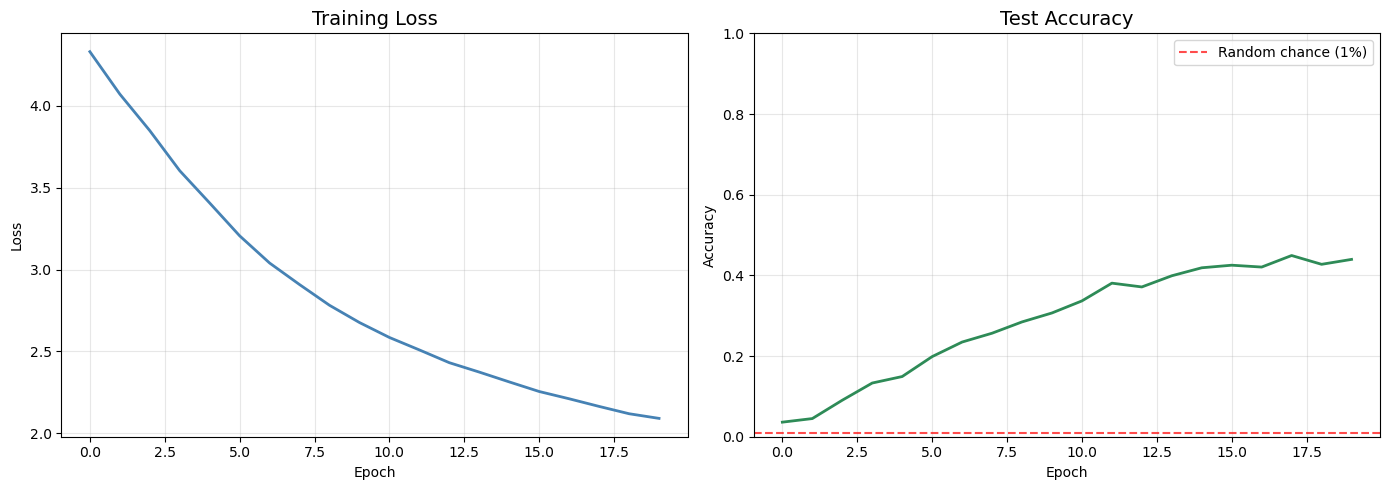

Final test accuracy: 43.96%


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(train_losses, marker='', linewidth=2, color='steelblue')
axes[0].set_title('Training Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(test_accuracies, marker='', linewidth=2, color='seagreen')
axes[1].set_title('Test Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=1/100, color='red', linestyle='--', alpha=0.7, label='Random chance (1%)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Final test accuracy: {test_accuracies[-1]:.2%}')

## Step 7: Per-Class Performance

Overall accuracy only tells part of the story. With 100 classes, the model will be great at some and terrible at others. Let's find out which.

In [35]:
model.eval()
class_correct = [0] * 100
class_total   = [0] * 100

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label] += 1

# Per-class accuracy
class_accuracies = []
for i in range(100):
    acc = class_correct[i] / max(class_total[i], 1)
    class_accuracies.append(acc)

# Show best and worst classes
classes = train_dataset.classes
class_accuracy_pairs = list(zip(classes, class_accuracies))
class_accuracy_pairs.sort(key=lambda x: x[1], reverse=True)

print('=== Top 10 Best Classified Classes ===')
for name, acc in class_accuracy_pairs[:10]:
    print(f'  {name:<25} {acc:.1%}')

print()
print('=== Top 10 Worst Classified Classes ===')
for name, acc in class_accuracy_pairs[-10:]:
    print(f'  {name:<25} {acc:.1%}')

=== Top 10 Best Classified Classes ===
  wardrobe                  95.0%
  orange                    91.0%
  road                      81.0%
  sunflower                 81.0%
  bottle                    79.0%
  palm_tree                 79.0%
  skyscraper                79.0%
  chair                     78.0%
  cloud                     78.0%
  castle                    74.0%

=== Top 10 Worst Classified Classes ===
  boy                       10.0%
  lizard                    10.0%
  seal                      9.0%
  rabbit                    7.0%
  dolphin                   5.0%
  woman                     4.0%
  mouse                     3.0%
  beaver                    2.0%
  lobster                   1.0%
  otter                     0.0%


## Step 8: Confusion Matrix (Coarse Classes)

CIFAR-100 has a hidden structure: the 100 fine classes are grouped into 20 **coarse classes** (e.g., *aquatic mammals*, *flowers*, *vehicles*). Let's see if the model confuses classes within the same coarse group more often.

Coarse classes (20):
   0: aquatic_mammals
   1: fish
   2: flowers
   3: food_containers
   4: fruit_and_vegetables
   5: household_electrical_devices
   6: household_furniture
   7: insects
   8: large_carnivores
   9: large_man-made_outdoor_things
  10: large_natural_outdoor_scenes
  11: large_omnivores_and_herbivores
  12: medium_mammals
  13: non-insect_invertebrates
  14: people
  15: reptiles
  16: small_mammals
  17: trees
  18: vehicles_1
  19: vehicles_2



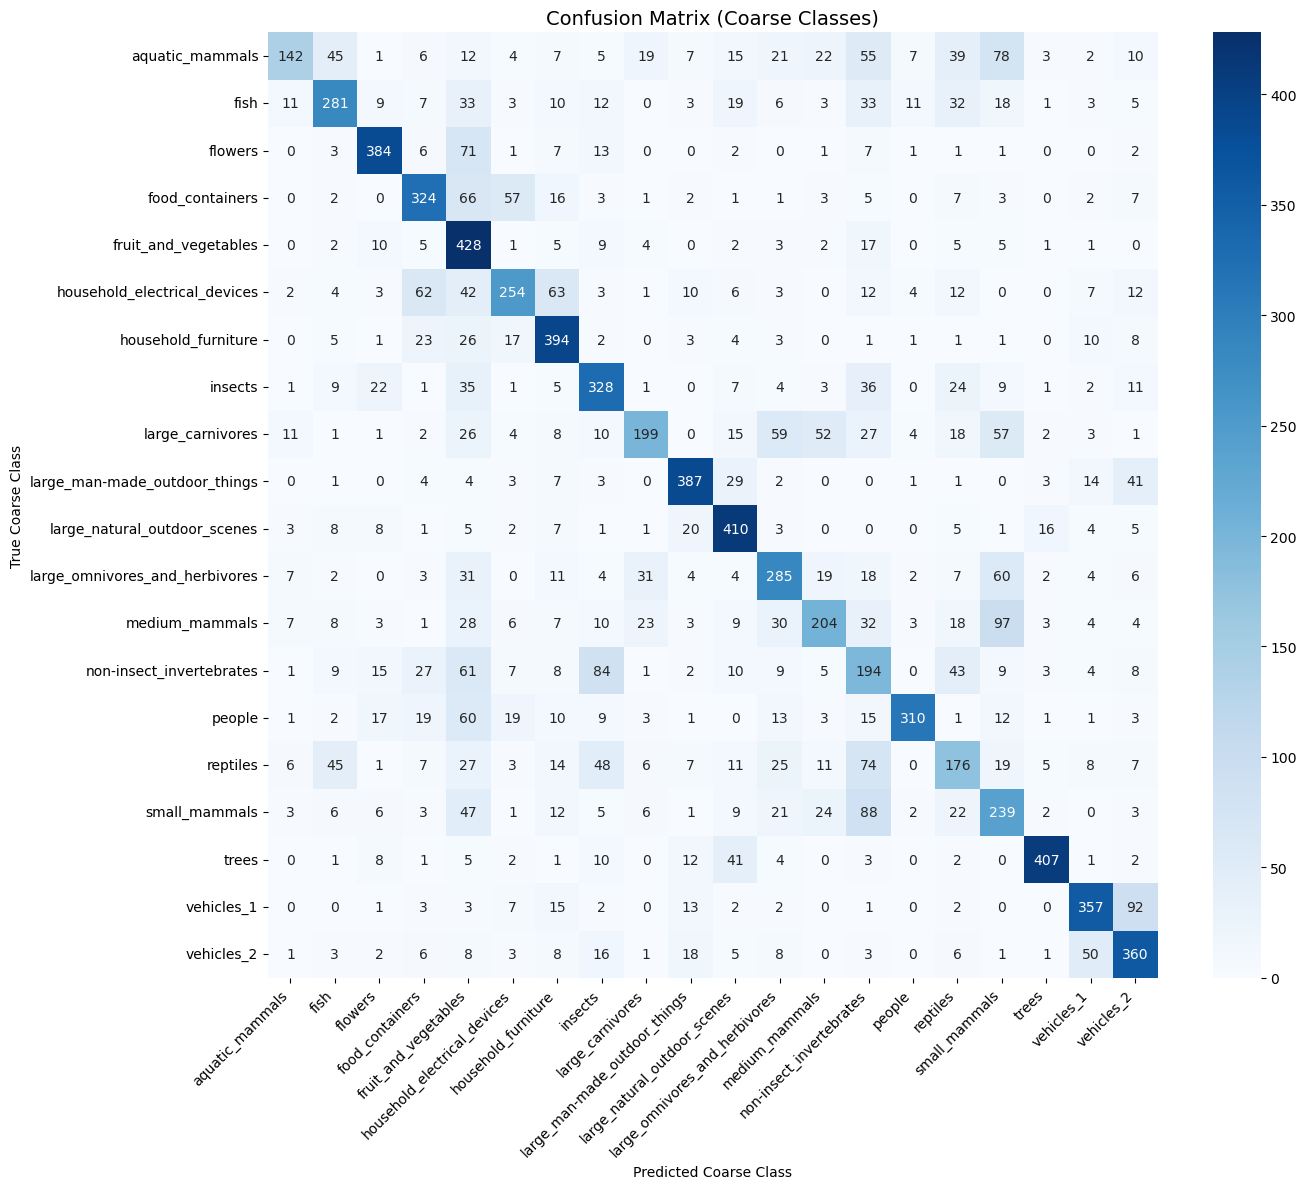

Coarse-level accuracy: 60.6%


In [36]:
import pickle as pkl

meta_path = data_dir / "cifar100" / "cifar-100-python" / "meta"
with open(meta_path, 'rb') as f:
    meta = pkl.load(f, encoding='bytes')

coarse_names = [name.decode('utf-8') for name in meta[b'coarse_label_names']]

# Build fine-to-coarse mapping from training data
train_path = data_dir / "cifar100" / "cifar-100-python" / "train"
with open(train_path, 'rb') as f:
    train_data = pkl.load(f, encoding='bytes')

fine_to_coarse_idx = {}
for fine, coarse in zip(train_data[b'fine_labels'], train_data[b'coarse_labels']):
    if fine not in fine_to_coarse_idx:
        fine_to_coarse_idx[fine] = coarse
fine_to_coarse_idx = [fine_to_coarse_idx[i] for i in range(100)]

print(f'Coarse classes ({len(coarse_names)}):')
for i, name in enumerate(coarse_names):
    print(f'  {i:2d}: {name}')
print()

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Map to coarse labels
coarse_preds  = [fine_to_coarse_idx[p] for p in all_preds]
coarse_labels = [fine_to_coarse_idx[l] for l in all_labels]

cm = confusion_matrix(coarse_labels, coarse_preds)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=coarse_names, yticklabels=coarse_names)
plt.title('Confusion Matrix (Coarse Classes)', fontsize=14)
plt.ylabel('True Coarse Class')
plt.xlabel('Predicted Coarse Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

coarse_accuracy = sum(1 for a, b in zip(coarse_preds, coarse_labels) if a == b) / len(coarse_labels)
print(f'Coarse-level accuracy: {coarse_accuracy:.1%}')

## Step 9: Look at Predictions

Green = correct, red = wrong. With 100 classes, the errors are especially interesting.

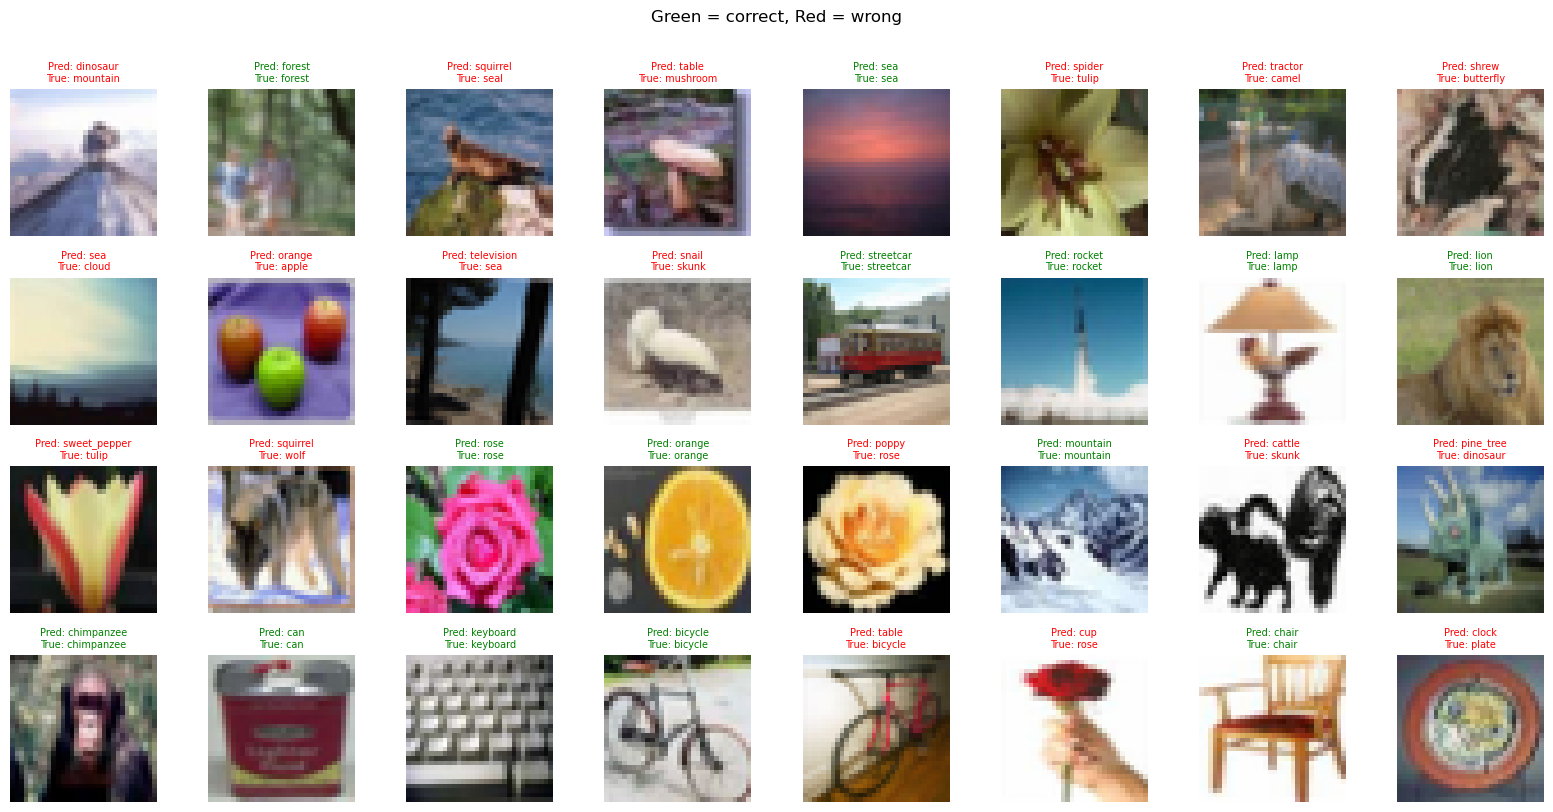

In [37]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)

    pred_name = classes[predicted[i].item()]
    true_name = classes[labels[i].item()]
    color = 'green' if predicted[i] == labels[i] else 'red'
    ax.set_title(f'Pred: {pred_name}\nTrue: {true_name}', fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Green = correct, Red = wrong', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## What You Built

A deep CNN from scratch that classifies 32×32 color images into **100 different categories**:

1. **Loaded CIFAR-100** — 60,000 color images with 100 fine-grained classes
2. **Applied data augmentation** — random flips, crops, and color jitter to improve generalization
3. **Built a deeper CNN** — 4 convolutional blocks with batch normalization
4. **Used learning rate scheduling** — StepLR to reduce LR over time
5. **Evaluated per-class performance** — identified which classes the model handles well vs. poorly
6. **Analyzed coarse-level confusion** — checked if errors make semantic sense

## Things to Try

1. **Add more convolutional layers** — does a 5th block help?
2. **Try different optimizers** — SGD with momentum instead of Adam
3. **Adjust the learning rate schedule** — try `CosineAnnealingLR` instead of `StepLR`
4. **Use label smoothing** — `nn.CrossEntropyLoss(label_smoothing=0.1)`
5. **Build a ResNet from scratch** — implementing skip connections
6. **Train a model on CIFAR-100 and then fine-tune** on a smaller dataset

---
## Bonus Challenge: Build a Mini-ResNet

If you want a real deep learning challenge, implement a **ResNet-18** from scratch. The key innovation: **skip connections** that let the gradient flow directly through the network, enabling much deeper architectures.

A ResNet basic block looks like:
```
x -> [Conv -> BN -> ReLU -> Conv -> BN] -> + -> ReLU -> output
  '----------------------------' (skip connection)
```

In [ ]:
# TODO: Implement a ResNet basic block, then stack blocks to build ResNet-18